In [193]:
import pandas as  pd 
import matplotlib.pyplot as plt 
import numpy as np
from SFstarred.save_and_read import read_hdf5_to_dict
from SFstarred.utils import correct_cutout_and_noise
from SFstarred.plots import plot_image_and_noisemap
import jax 
jax.config.update("jax_enable_x64", True) #we require double digit precision, this can be removed on GPU

In [194]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model
from copy import deepcopy
from pprint import pprint
from starred.procedures.deconvolution_routines import multi_steps_deconvolution
from starred.plots.plot_function import view_deconv_model, plot_loss, plot_deconvolution
from SFstarred.stars_cut import normalize_data_error,normalize_data_error_photutils
from SFstarred.plots import plot_lens_and_noisemap,plot_star_mask

In [195]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [196]:
# zp_ab= data_dict["zp_ab"]

## Overview

This notebook applies the image-deconvolution procedure presented in the `start_here.ipynb` notebook from `starred`.

In [197]:
narrow_psfs = np.load('data_for_starred/narrow_psfs.npy')
#narrow_psfs = np.load('data_for_starred/narrow_psfs_hst.npy')

# if len(narrow_psfs.shape)==2:
# 	narrow_psfs = narrow_psfs[None,:]

In [198]:
def from223(array):
    if len(array.shape) == 2:
        return array[None,:,:]
    else:
        return array 

In [199]:
data_dict = pd.read_pickle("data_for_starred/dfs_lenstronomy.pickle")
data = from223(data_dict["system_cutout"])
im_size = data.shape[-1]
sigma2 = from223(data_dict["sigma2_system"])
narrow_psfs = from223(narrow_psfs)
image_positions = data_dict["coord_pix_images"]
scale = np.max(data)
#image_names = data_dict["images_names"]
#coord_pix_images_dict = data_dict["coord_pix_images_dict"]



In [200]:
data.shape

(1, 128, 128)

In [201]:
sigma2 /=scale**2
data /=scale

(array([1.6326e+04, 2.7000e+01, 9.0000e+00, 8.0000e+00, 7.0000e+00,
        0.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([2.44791334e-08, 2.19452295e-06, 4.36456685e-06, 6.53461075e-06,
        8.70465465e-06, 1.08746981e-05, 1.30447424e-05, 1.52147868e-05,
        1.73848312e-05, 1.95548746e-05, 2.17249180e-05]),
 <BarContainer object of 10 artists>)

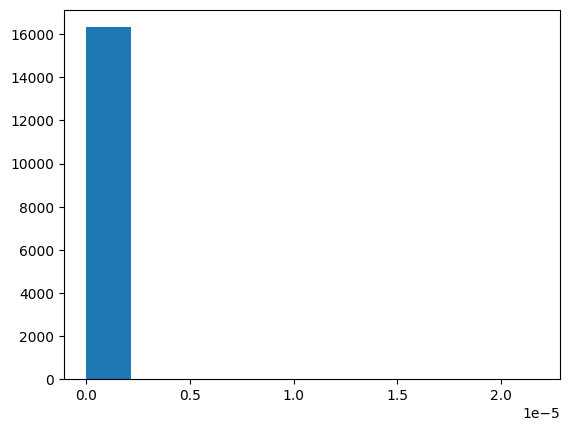

In [202]:
plt.hist(sigma2.ravel())

In [203]:
#sigma2 = sigma2*172

In [204]:
# fig, ax = plot_lens_and_noisemap(
#     data=data[0],
#     noisemaps=noise_map[0],
#     image_positions=image_positions,
#     image_names=image_names,
#     #vmin=np.nanpercentile(data, 1),
#     #vmax=np.nanpercentile(data, 99),
#     #noise_vmin=np.nanpercentile(noisemaps, 1),
#     #noise_vmax=np.nanpercentile(noisemaps, 99),
# )
# plt.show()

offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset

ys = image_positions[:,1] - offset
try:
	coord_pix_non_images = data_dict["coord_pix_non_images"]
	ptx_non_lens = coord_pix_non_images[:,0] - offset
	pty_non_lens = coord_pix_non_images[:,1] - offset
except:
     print("no extra obj")
# xs = np.array([coord_pix_images_dict[name][0] for name in 'ABCD']) - offset
# ys = np.array([coord_pix_images_dict[name][1] for name in 'ABCD']) - offset

#
#np.median(data[0]),np.median(noisemaps[0])
print(xs)
print(ys)
# scale = np.nanmax(data)
# data /=scale
# noise_map /=scale
# sigma2 = noise_map**2




no extra obj
[  3.09565119 -15.01530028  22.24557658  -6.94104286]
[-17.35525799  -7.64560512   6.59512208  14.54651568]


/Users/felavila/Work/Packages/starred/starred/deconvolution/deconvolution.py:82: UserWarning: The narrow PSF does not have the same size as the upsampled image. This might be desired to speed up the computation but make sure it is at the resolution of the upsampled image.
  warnings.warn(


{'kwargs_analytic': {'c_x': array([  3.09565119, -15.01530028,  22.24557658,  -6.94104286]), 'c_y': array([-17.35525799,  -7.64560512,   6.59512208,  14.54651568]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([ 4.47082581, 10.84757181,  5.93578779,  8.16018659])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(65536,)), 'mean': array([0.])}}


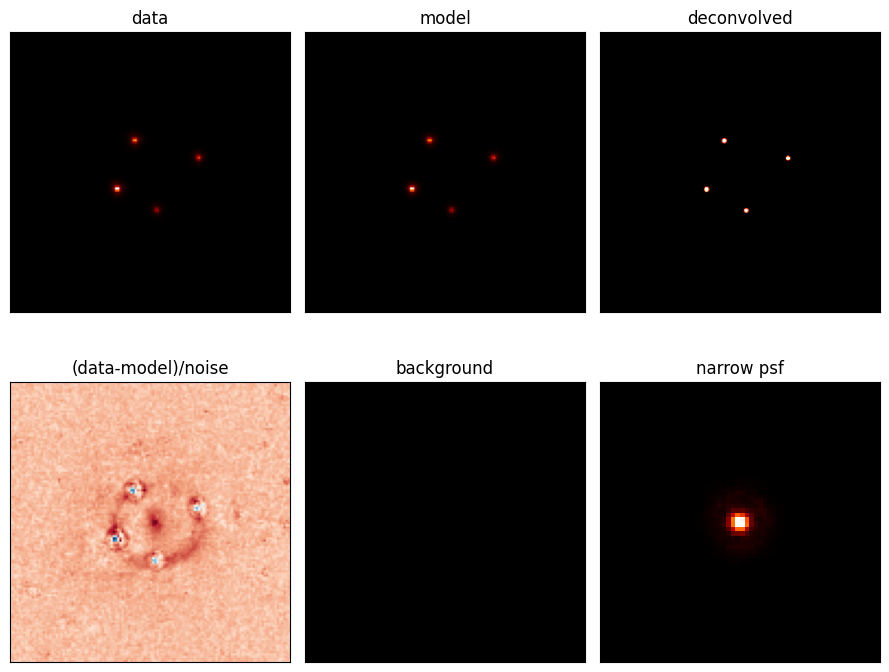

In [205]:
initial_c_x = xs
initial_c_y = ys


brightnesses = [4.47082581, 10.84757181,  5.93578779,  8.16018659]
subsampling_factor = 2
model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(
    data,
    sigma2,
    narrow_psfs,
    initial_c_x,
    initial_c_y,
    subsampling_factor=subsampling_factor,
    initial_a=brightnesses,
    N_sersic=0,
)

# kwargs_init['kwargs_sersic']['amp'][0] = 0.01
# kwargs_init['kwargs_sersic']['e1'][0] = -0.1
# kwargs_init['kwargs_sersic']['e2'][0] = -0.1
# kwargs_init['kwargs_sersic']['center_x'][0] = 2.41209164
# kwargs_init['kwargs_sersic']['center_y'][0] = -1

parameters = ParametersDeconv(
    kwargs_init,
    kwargs_fixed,
    kwargs_up=kwargs_up,
    kwargs_down=kwargs_down,
)

print(kwargs_init)
view_deconv_model(model, kwargs_init, data,sigma2)

In [206]:
output = model.model(kwargs_init)
psf = model.psf
noisemap = sigma2 ** 0.5
rms = (data[0] - output[0]) / noisemap[0]

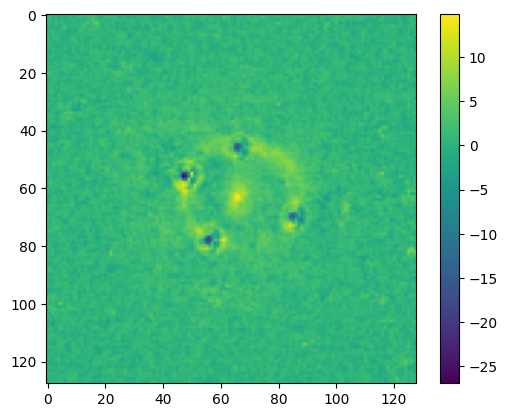

In [207]:
plt.imshow(rms)
plt.colorbar()

Step 1, fixing : ['background']
Step 1/1 took  1 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([ 4.4677198 , 10.84582552,  5.93263878,  8.15607769], dtype=float64), 'c_x': Array([  3.13717744, -14.94602699,  22.25340737,  -6.89158546], dtype=float64), 'c_y': Array([-17.33516468,  -7.63181515,   6.61446649,  14.55728933], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  27415.676123953715
Overall Reduced Chi2 :  3.346640151849

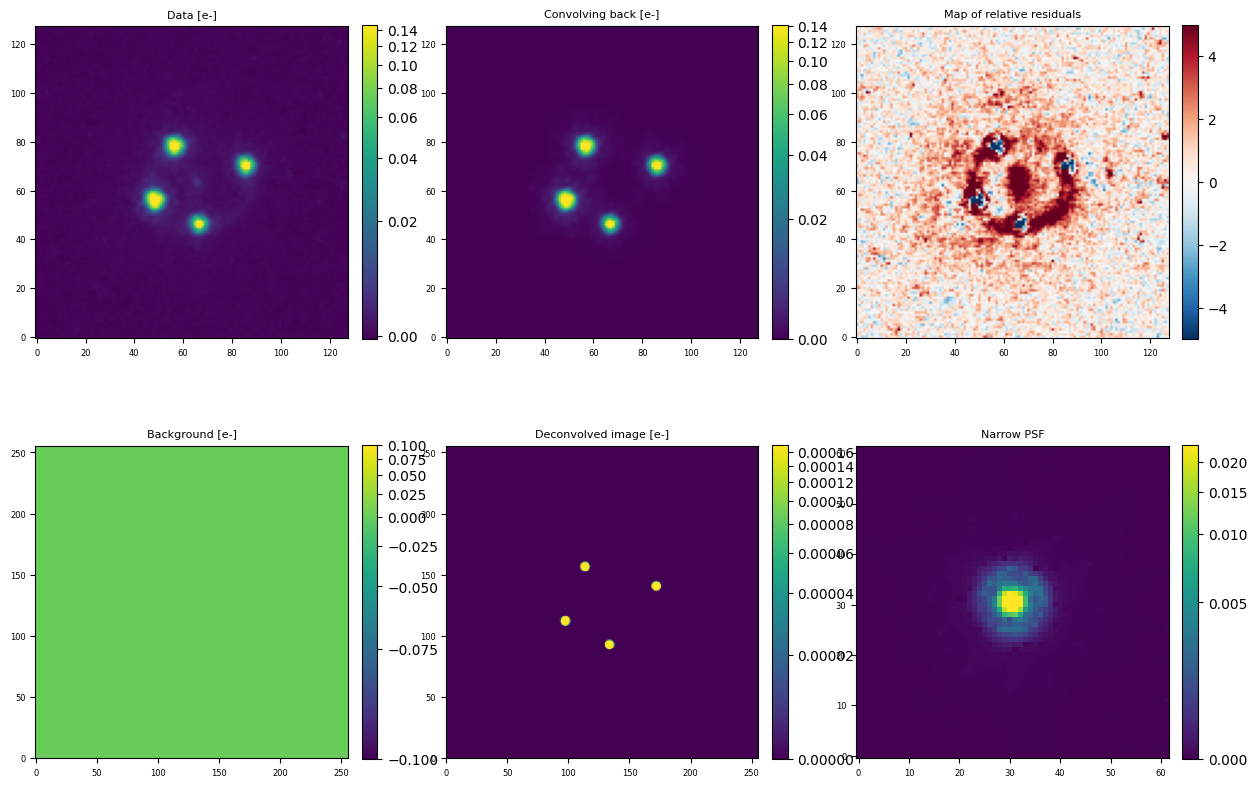

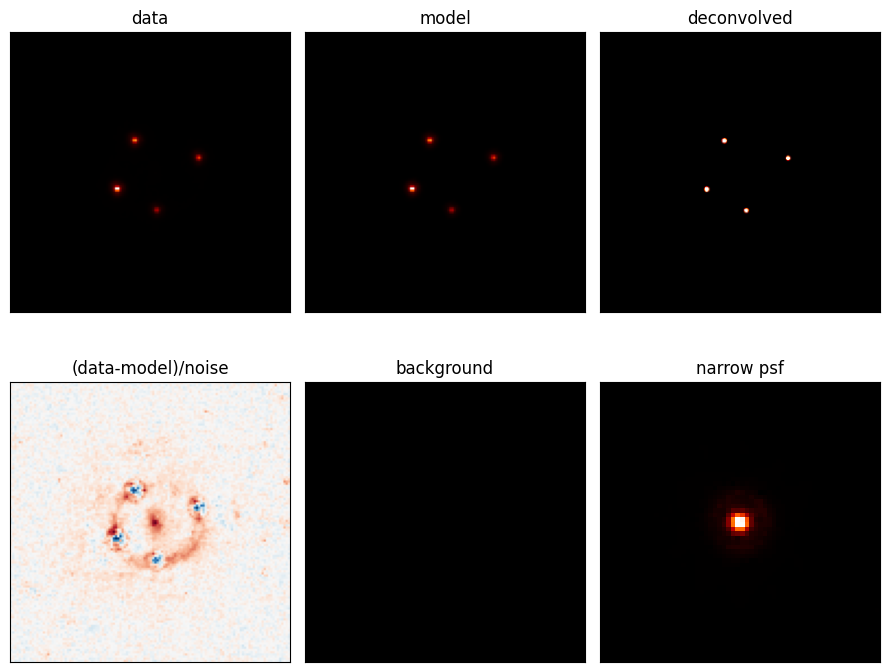

In [208]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                   # []
                    #['background'], #step 2: release astrometry, keep the pixelated background constant.
                     #   ['pts-source-photometry']
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b']#,'l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':70}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs]#, kwargs_lbfgs,kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None]#,None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, lambda_positivity_bkg=0,
                                                                                    lambda_positivity_ps=0, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
#pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data, sigma2)

146.68745824602414
217.6206111061407
204.16862729230883
155.51000760457967
93.84058512431396
49.37244521204238
24.376205040587358
10.813297171245825
4.7605712050641795


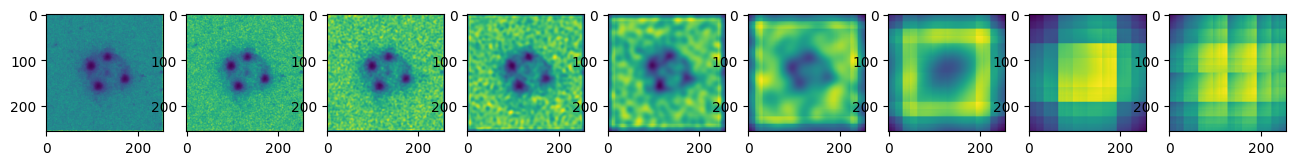

In [209]:
W = propagate_noise(model, np.sqrt(sigma2), kwargs_init, wavelet_type_list=['starlet'], 
                    method='MC', num_samples=100, seed=1, likelihood_type='chi2', 
                    
                    verbose=False, upsampling_factor=subsampling_factor)[0]

gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
for i, l in enumerate(W):
    axs[i].imshow(l)
    print(np.mean(l))
plt.show()

Step 1, fixing : ['pts-source-astrometry']


optax.adabelief: 100%|██████████| 1000/1000 [00:07<00:00, 131.03it/s]


Step 1/1 took  8 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([ 4.43815582, 10.79159067,  5.89953117,  8.11454412], dtype=float64), 'c_x': Array([  3.13717744, -14.94602699,  22.25340737,  -6.89158546], dtype=float64), 'c_y': Array([-17.33516468,  -7.63181515,   6.61446649,  14.55728933], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([-2.53205208e-03,  1.35535911e-06,  1.53922138e-03, ...,
        2.33048318e-06, -2.04765891e-06,  1.76686508e-08], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  1679

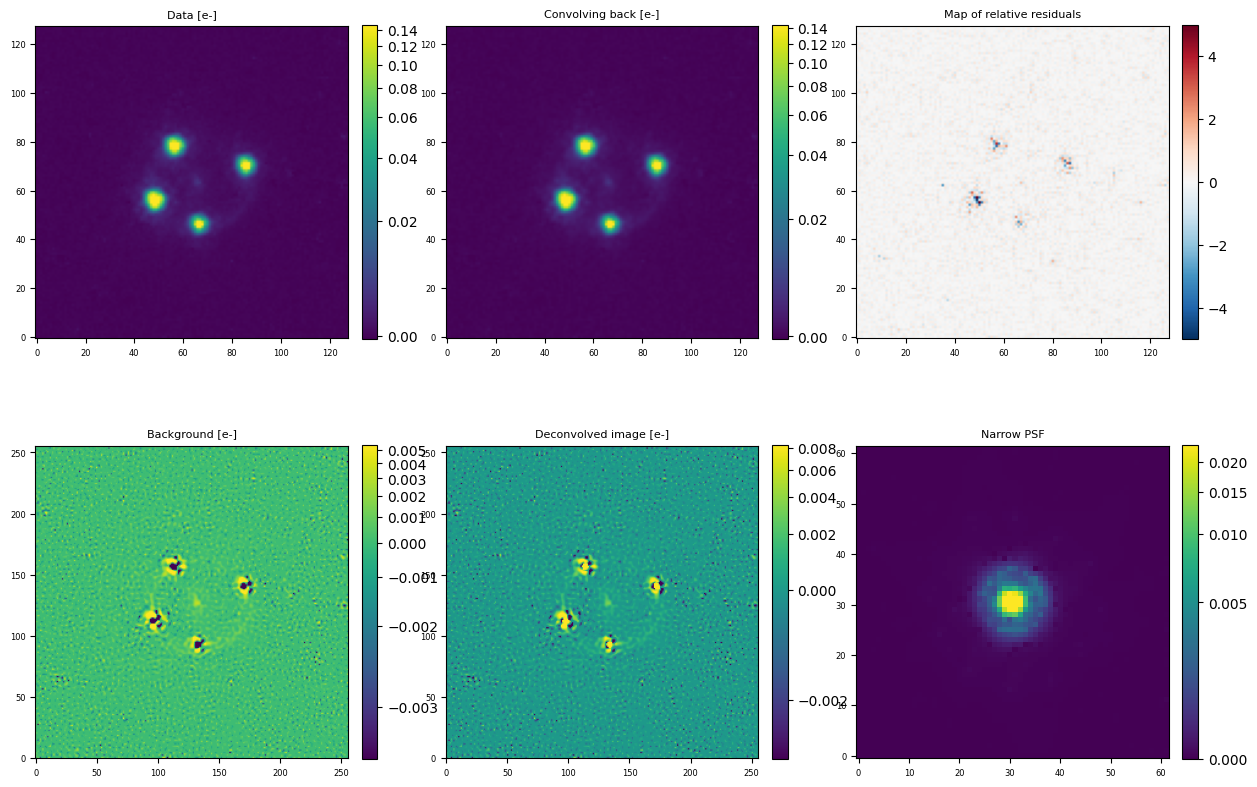

In [218]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry'],
                    #[]
                    #['sersic', 'pts-source-astrometry'], #step 1 : fix the Sersic profile and the astrometry, release the background
                    #['sersic'],
        ]
    
optim_list = ['adabelief']
kwargs_optax1 = {'max_iterations': 1_000, 'min_iterations': None,
        'init_learning_rate': 1e-5, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optim_list = [kwargs_optax1] 

prior_list=[None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)
#for ls in np.arange(1,5):
model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, 
                                                                                    lambda_positivity_ps=100,
                                                                                    lambda_positivity_bkg=100,
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

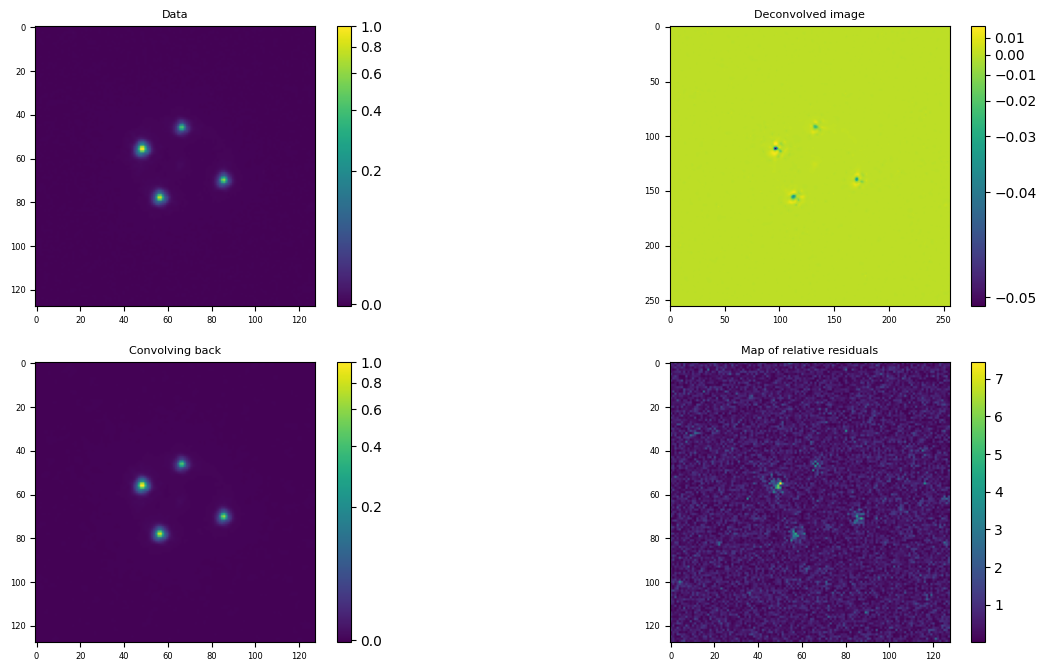

In [215]:
# Retrieving different elements of the deconvolved image
kwargs_partial_2 = deepcopy(parameters.best_fit_values(as_kwargs=True))
epoch = 0
output = model.model(kwargs_partial_2)[epoch]
deconv, h = model.getDeconvolved(kwargs_partial_2, epoch)

data_show = data[epoch,:,:] 

dif = data_show - output
rr = np.abs(dif)/ np.sqrt(sigma2[epoch,:,:])

fig, axs = plt.subplots(2, 2, figsize=(15,8))
fraction = 0.046
pad = 0.04
font_size = 10
ticks_size = 6

from astropy.visualization import (imshow_norm, MinMaxInterval,
                                   SqrtStretch, AsinhStretch)
stretch = AsinhStretch

plt.rc('font', size=font_size)           
axs[0,0].set_title('Data', fontsize=8)
axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[0,1].set_title('Deconvolved image', fontsize=8)
axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,0].set_title('Convolving back', fontsize=8)
axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,1].set_title('Map of relative residuals', fontsize=8)
axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
plt.show()


Step 1, optimiser adabelief
Overall Reduced Chi2 :  0.09355612839757071


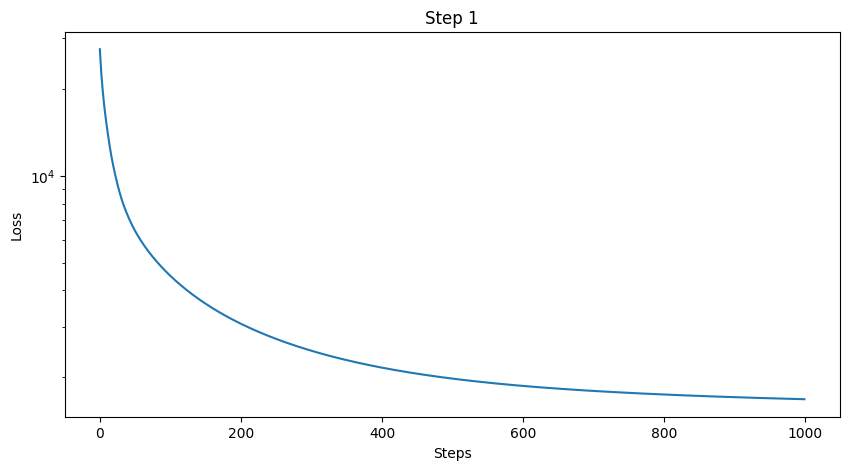

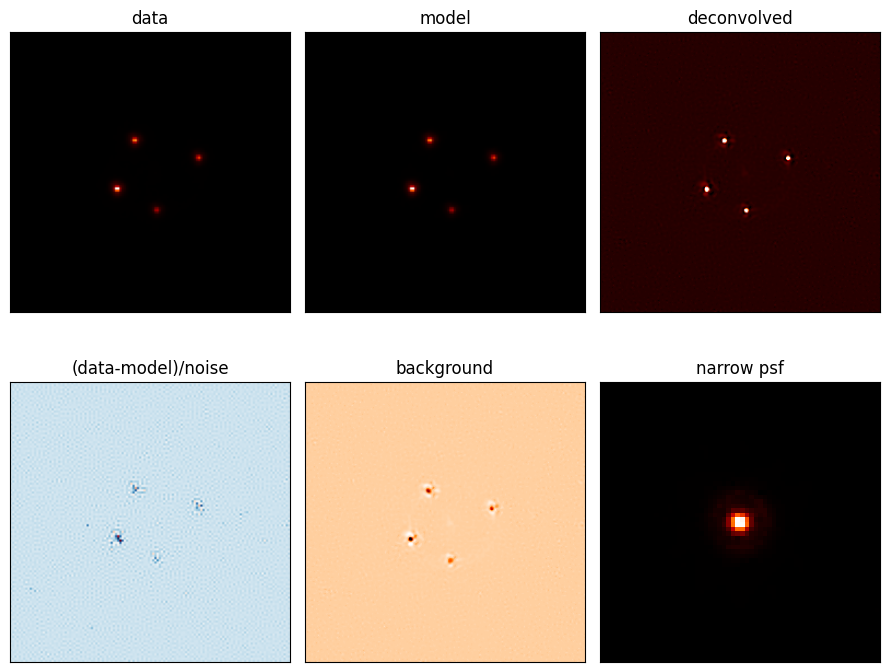

In [213]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_partial_2))
view_deconv_model(model, kwargs_partial_2, data, sigma2)

Step 1, fixing : []


optax.adabelief: 100%|██████████| 2000/2000 [00:15<00:00, 130.14it/s]


Step 1/1 took 16 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([ 4.26273965, 10.60601969,  5.79510816,  7.91182222], dtype=float64), 'c_x': Array([  3.11537684, -14.96554491,  22.24418191,  -6.91748244], dtype=float64), 'c_y': Array([-17.35066495,  -7.65659387,   6.6024634 ,  14.54720113], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([-2.67407979e-06,  3.58403836e-06, -1.65873256e-06, ...,
        1.72924782e-05,  1.08098878e-05,  1.38966628e-05], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  7111

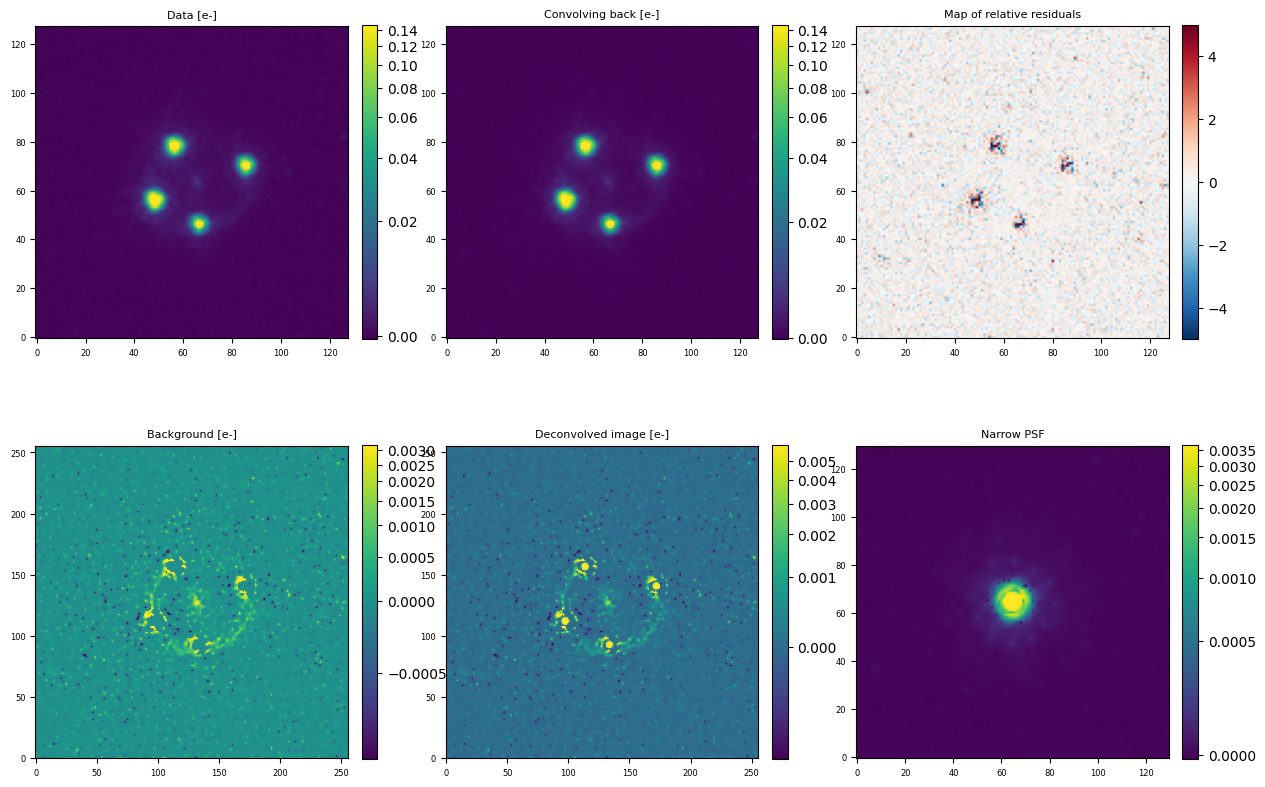

In [103]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [[]
                    #['sersic', 'pts-source-astrometry'], #step 1 : fix the Sersic profile and the astrometry, release the background
                    #['sersic'],
        ]
    
optim_list = ['adabelief']
kwargs_optax1 = {'max_iterations': 2000, 'min_iterations': None,
        'init_learning_rate': 3e-5, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
# kwargs_optax2 = {
#         'max_iterations': 500, 'min_iterations': None,
#         'init_learning_rate': 1e-3, 'schedule_learning_rate': True,
#         'restart_from_init': False, 'stop_at_loss_increase': False,
#         'progress_bar': True, 'return_param_history': True
#     }
kwargs_optim_list = [kwargs_optax1] 
prior_list=[None]

parameters = ParametersDeconv(kwargs_partial_2, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 4, lambda_hf =4, 
                                                                                    lambda_positivity_ps=1000,
                                                                                    lambda_positivity_bkg=1000, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

In [53]:
subsampling_factor

4

Step 1, optimiser adabelief
{'kwargs_analytic': {'a': Array([ 5.51641233,  4.05708293,  7.54280417, 10.11834201], dtype=float64), 'c_x': Array([ 19.24897679,   0.12224423,  -9.90844046, -17.95241177], dtype=float64), 'c_y': Array([  8.59393674, -15.35553083,  16.54041726,  -5.67534687], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([ 7.84507462e-06,  7.32487219e-06,  3.35753307e-06, ...,
        2.56155252e-06, -5.29541387e-06,  3.21439240e-06], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Overall Reduced Chi2 :  0.9198173347

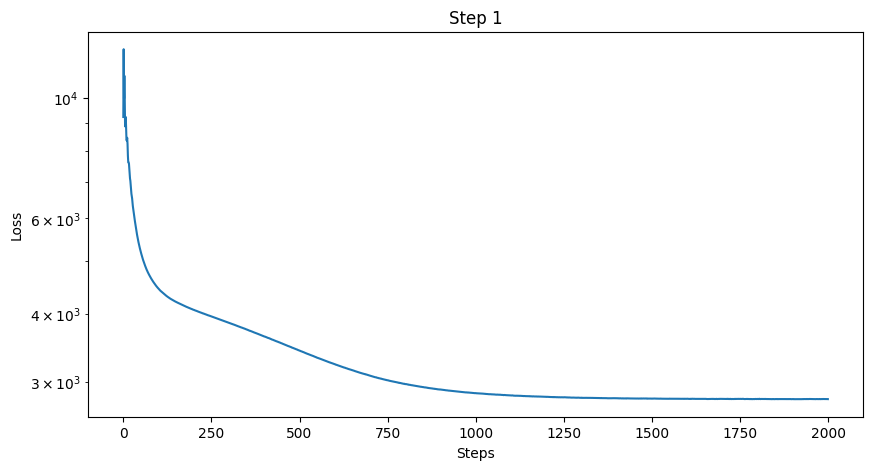

In [54]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

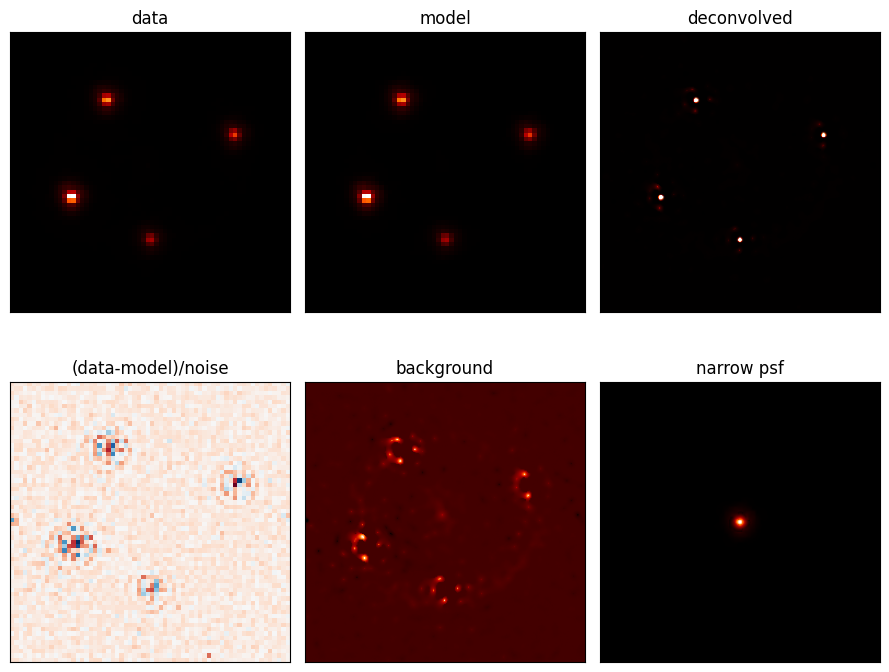

In [55]:
view_deconv_model(model, kwargs_final, data, sigma2)

In [56]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_final)[epoch]
deconv, h = model.getDeconvolved(kwargs_final, epoch)

data_show = data[epoch,:,:] 

dif = data_show - output
rr = np.abs(dif)/ np.sqrt(sigma2[epoch,:,:])

(array([3.458e+03, 4.940e+02, 7.800e+01, 2.500e+01, 2.200e+01, 7.000e+00,
        6.000e+00, 1.000e+00, 3.000e+00, 2.000e+00]),
 array([4.77659919e-04, 9.97124861e-01, 1.99377206e+00, 2.99041926e+00,
        3.98706646e+00, 4.98371366e+00, 5.98036086e+00, 6.97700806e+00,
        7.97365526e+00, 8.97030247e+00, 9.96694967e+00]),
 <BarContainer object of 10 artists>)

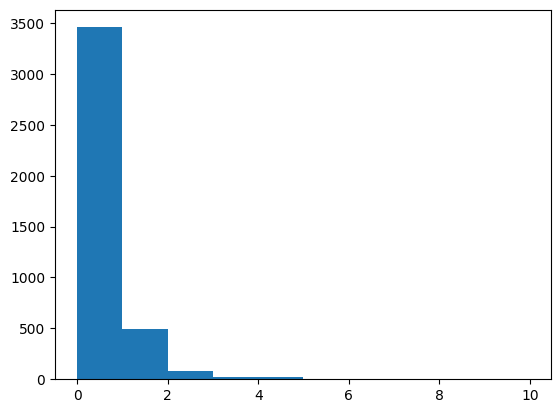

In [57]:
plt.hist(rr.ravel())

(array([2.000e+00, 3.000e+00, 8.000e+00, 2.200e+01, 4.008e+03, 4.000e+01,
        5.000e+00, 4.000e+00, 1.000e+00, 3.000e+00]),
 array([-0.0243841 , -0.01900384, -0.01362357, -0.00824331, -0.00286304,
         0.00251722,  0.00789749,  0.01327775,  0.01865802,  0.02403828,
         0.02941855]),
 <BarContainer object of 10 artists>)

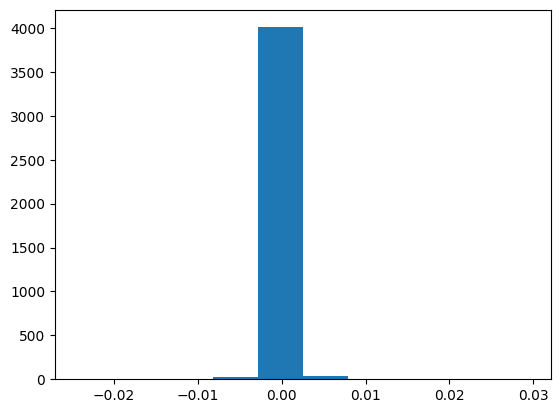

In [58]:
plt.hist((data_show - output).ravel())

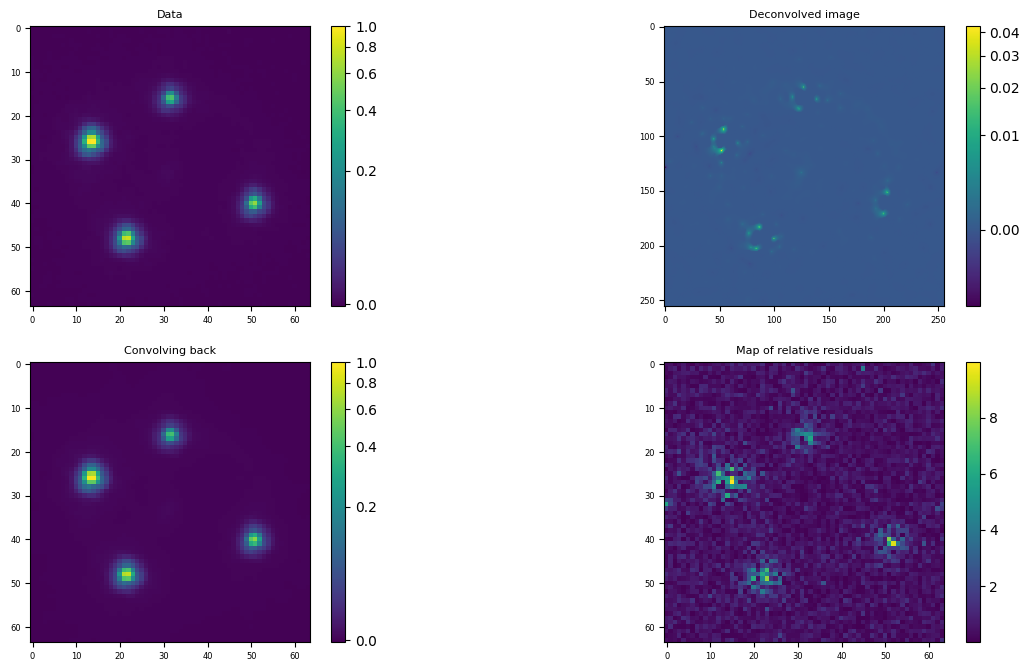

In [59]:
fig, axs = plt.subplots(2, 2, figsize=(15,8))
fraction = 0.046
pad = 0.04
font_size = 10
ticks_size = 6

from astropy.visualization import (imshow_norm, MinMaxInterval,
                                   SqrtStretch, AsinhStretch)
stretch = AsinhStretch

plt.rc('font', size=font_size)           
axs[0,0].set_title('Data', fontsize=8)
axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[0,1].set_title('Deconvolved image', fontsize=8)
axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,0].set_title('Convolving back', fontsize=8)
axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,1].set_title('Map of relative residuals', fontsize=8)
axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
plt.show()

In [413]:
input_flux = data.sum()
output_flux = output.sum()

print('Data flux: ' + str(input_flux))
print('Deconvolved image flux: ' + str(output_flux))
print('Flux change: ' + str(100 * abs(input_flux-output_flux) / input_flux) + '%')

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

Data flux: 30.115730538828
Deconvolved image flux: 30.68349813216697
Flux change: 1.8852858063892954%
Overall Reduced Chi2 :  0.038384693129304086


In [32]:
import warnings

from starred.deconvolution.loss import Loss as deconvLoss
from starred.psf.loss import Loss as psfLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf
from starred.psf.parameters import ParametersPSF

from copy import deepcopy
import numpy as np


def multi_steps_deconvolution(data, model, parameters, sigma_2, s, subsampling_factor,
                              fitting_sequence=[['background'], ['pts-source-astrometry'], []],
                              optim_list=['l-bfgs-b', 'adabelief', 'adabelief'], kwargs_optim_list=None,
                              lambda_scales=1., lambda_hf=1000., lambda_positivity_bkg=100, lambda_positivity_ps=100,
                              lambda_pts_source=0., prior_list=None, regularize_full_model=False,num_samples_noise=500,
                              update_lambda_pts_source=False,
                              adjust_sky=False, noise_propagation='MC', regularization_terms='l1_starlet',
                              verbose=True):
    """
    A high-level function to run several time the optimization algorithms and ensure to find the optimal solution.

    :param data: 3D array containing the images, one per epoch. shape (epochs, im_size, im_size)
    :param model: Deconv class, deconvolution model
    :param parameters: ParametersDeconv class
    :param sigma_2: 3D array containing the noisemaps, one per epoch. shape (epochs, im_size, im_size)
    :param s: 3D array containing the narrow PSFs, one per epoch. shape (epochs, im_size_up, im_size_up) where im_size_up needs be a multiple of im_size.
    :param subsampling_factor: integer, ratio of the size of the data pixels to that of the PSF pixels.
    :param fitting_sequence: list, List of lists, containing the element of the model to keep fixed. Example : [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
    :param optim_list: List of optimiser. Recommended if background is kept constant : 'l-bfgs-b', 'adabelief' otherwise.
    :param kwargs_optim_list: List of dictionary, containing the setting for the different optimiser.
    :param lambda_scales: Lagrange parameter that weights intermediate scales in the transformed domain
    :param lambda_hf: Lagrange parameter weighting the highest frequency scale
    :param lambda_pts_source: Lagrange parameter regularising the pts source channel
    :param lambda_positivity_bkg: Lagrange parameter weighting the positivity of the background. 0 means no positivity constraint.
    :param lambda_positivity_ps: Lagrange parameter weighting the positivity of the point sources. 0 means no positivity constraint.
    :param regularize_full_model: option to regularise just the background (False, recommended) or background + point source channel (True)
    :param update_lambda_pts_source : bool, option to refine the points channel regularization strength at every iteration
    :param prior_list: list of Prior object, Gaussian prior on parameters to be applied at each step
    :param adjust_sky: bool, True if you want to fit some sky subtraction
    :param noise_propagation: 'MC' or 'SLIT', method to compute the noise propagation in wavelet space. Default: 'MC'.
    :param verbose: bool. Verbosity.

    Return model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list
    """
    # Check the sequence
    assert len(fitting_sequence) == len(optim_list), "Fitting sequence and optimiser list have different lenght !"
    if kwargs_optim_list is not None:
        assert len(fitting_sequence) == len(
            kwargs_optim_list), "Fitting sequence and kwargs optimiser list have different lenght !"
    else:
        warnings.warn('No optimiser kwargs provided. Default configuration is used.')
        kwargs_optim_list = [{} for _ in range(len(fitting_sequence))]

    if prior_list is None:
        prior_list = [None for _ in range(len(fitting_sequence))]
    else:
        assert len(fitting_sequence) == len(prior_list), "Fitting sequence and prior list have different lenght !"

    # setup the model
    kwargs_init, kwargs_fixed_default, kwargs_up, kwargs_down = deepcopy(parameters._kwargs_init), deepcopy(
        parameters._kwargs_fixed), \
        deepcopy(parameters._kwargs_up), deepcopy(parameters._kwargs_down)
    if not adjust_sky:
        kwargs_fixed_default['kwargs_background']['mean'] = np.zeros(model.epochs)

    kwargs_partial_list = [kwargs_init]
    fig_list = []
    loss_history_list = []
    loss_list = []

    W = propagate_noise(model, np.sqrt(sigma_2), kwargs_init, wavelet_type_list=['starlet'],
                        method=noise_propagation,
                        num_samples=num_samples_noise, seed=1, likelihood_type='chi2', verbose=False,
                        upsampling_factor=subsampling_factor)[0]

    for i, steps in enumerate(fitting_sequence):
        kwargs_fixed = deepcopy(kwargs_fixed_default)
        background_free = True
        for fixed_feature in steps:
            if fixed_feature == 'pts-source-astrometry':
                kwargs_fixed['kwargs_analytic']['c_x'] = kwargs_partial_list[i]['kwargs_analytic']['c_x']
                kwargs_fixed['kwargs_analytic']['c_y'] = kwargs_partial_list[i]['kwargs_analytic']['c_y']
            elif fixed_feature == 'pts-source-photometry':
                kwargs_fixed['kwargs_analytic']['a'] = kwargs_partial_list[i]['kwargs_analytic']['a']
            elif fixed_feature == 'background':
                background_free = False
                kwargs_fixed['kwargs_background']['h'] = kwargs_partial_list[i]['kwargs_background']['h']
            elif fixed_feature == 'sersic':
                for k in kwargs_partial_list[i]['kwargs_sersic'].keys():
                    kwargs_fixed['kwargs_sersic'][k] = kwargs_partial_list[i]['kwargs_sersic'][k]
            elif fixed_feature == 'dithering':
                kwargs_fixed['kwargs_analytic']['dx'] = kwargs_partial_list[i]['kwargs_analytic']['dx']
                kwargs_fixed['kwargs_analytic']['dy'] = kwargs_partial_list[i]['kwargs_analytic']['dy']
            else:
                raise ValueError(
                    'Steps is not defined. Choose between "pts-source-astrometry", "pts-source-photometry", "background", "dithering" or "sersic".')

        # need to recompile the parameter class, since we have changed the number of free parameters
        parameters = ParametersDeconv(kwargs_partial_list[i], kwargs_fixed, kwargs_up=kwargs_up,
                                      kwargs_down=kwargs_down)

        # for speed-up we turn of the regularization to avoid the starlet decomposition, if the background is fixed
        if background_free:
            lambda_scales_eff, lambda_hf_eff, lambda_positivity_bkg_eff = deepcopy(lambda_scales), deepcopy(
                lambda_hf), deepcopy(lambda_positivity_bkg)
        else:
            lambda_scales_eff, lambda_hf_eff, lambda_positivity_bkg_eff = 0., 0., 0.

        # refine the regularization of the point source channel correction from previous iteration
        if i > 0 and update_lambda_pts_source and lambda_pts_source != 0:
            lambda_pts_prev = lambda_pts_source_eff
            lambda_pts_source_eff = loss.update_lambda_pts_source(kwargs_partial_list[i])
            if verbose:
                print(f'Updating lambda_pts_source from {lambda_pts_prev} to {lambda_pts_source_eff}')
        else:
            lambda_pts_source_eff = lambda_pts_source

            # run the optimization
        print('Step %i, fixing :' % (i + 1), steps)
        loss = deconvLoss(data, model, parameters, sigma_2, regularization_terms=regularization_terms,
                          regularization_strength_scales=lambda_scales_eff,
                          regularization_strength_hf=lambda_hf_eff,
                          regularization_strength_positivity=lambda_positivity_bkg_eff,
                          regularization_strength_positivity_ps=lambda_positivity_ps,
                          regularization_strength_pts_source=lambda_pts_source_eff,
                          regularize_full_model=regularize_full_model,
                          prior=prior_list[i], W=W, )

        optim = Optimizer(loss, parameters, method=optim_list[i])
        best_fit, loss_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim_list[i])

        # Saving partial results
        kwargs_partial_steps = deepcopy(parameters.best_fit_values(as_kwargs=True))
        fig_list.append(
            pltf.plot_deconvolution(model, data, sigma_2, s, kwargs_partial_steps, epoch=0, units='e-', cut_dict=None))
        loss_history_list.append(extra_fields['loss_history'])
        loss_list.append(loss_best_fit)

        kwargs_partial_list.append(deepcopy(kwargs_partial_steps))
        if verbose:
            print('Step %i/%i took %2.f seconds' % (i + 1, len(fitting_sequence), runtime))
            print('Kwargs partial at step %i/%i' % (i + 1, len(fitting_sequence)), kwargs_partial_steps)
            print('Loss : ', loss_best_fit)
            print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_partial_steps))

    return model, parameters, loss, kwargs_partial_list, fig_list, loss_list, loss_history_list


Step 1, fixing : ['background']
Step 1/1 took  0 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([ 6.02125904,  4.44129658,  8.20584557, 10.99418642], dtype=float64), 'c_x': Array([ 22.22660649,   3.09483586,  -6.93153875, -14.98399308], dtype=float64), 'c_y': Array([  3.60035081, -20.35218831,  11.54333167, -10.65982162], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  17190.92791033253
Overall Reduced Chi2 :  8.3940077687170

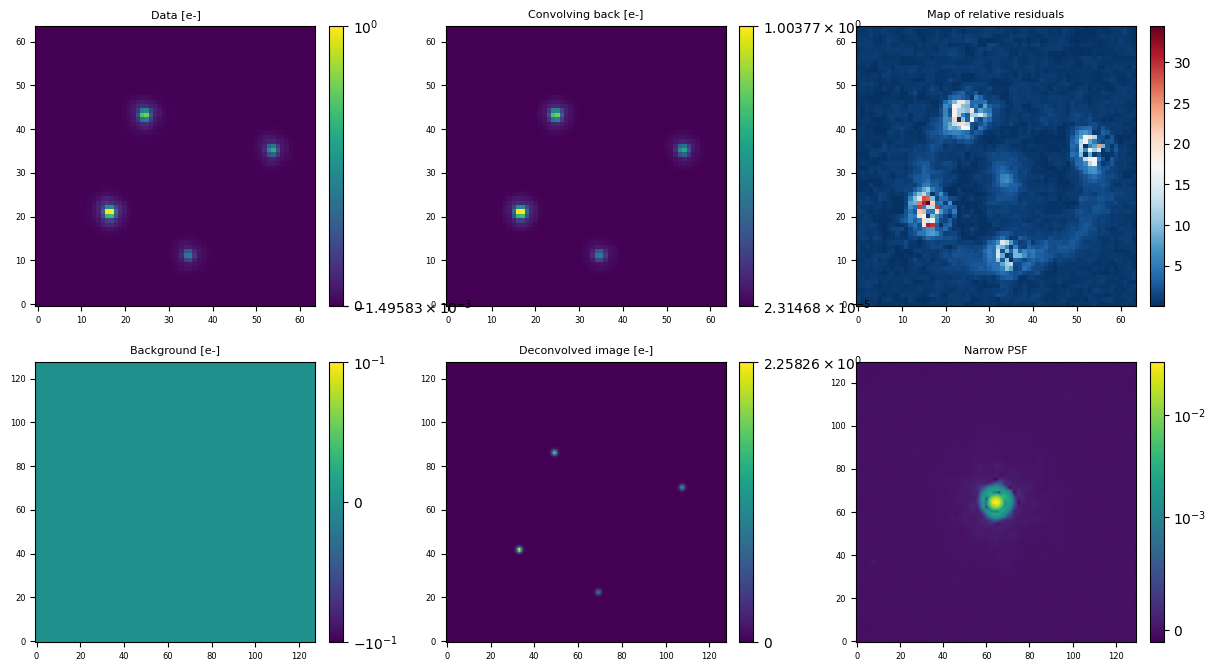

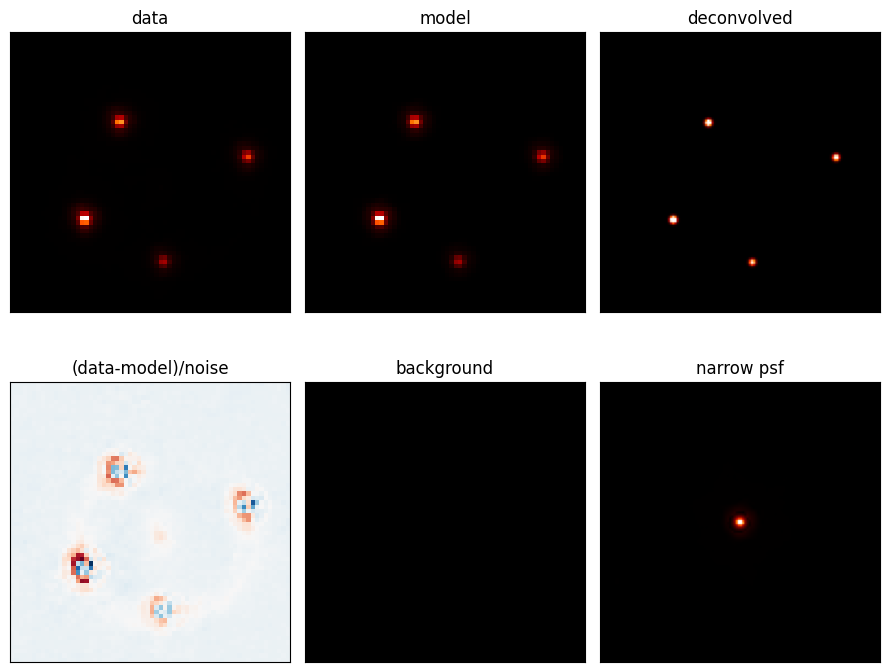

Step 1, fixing : ['pts-source-astrometry']


optax.adabelief: 100%|██████████| 500/500 [00:03<00:00, 159.74it/s]


Step 1/1 took  3 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([ 5.97526295,  4.37326073,  8.15455703, 10.93180772], dtype=float64), 'c_x': Array([ 22.22660649,   3.09483586,  -6.93153875, -14.98399308], dtype=float64), 'c_y': Array([  3.60035081, -20.35218831,  11.54333167, -10.65982162], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([1.89899730e-05, 1.68915733e-05, 3.02662483e-05, ...,
       2.81303029e-05, 1.55296693e-05, 1.62336796e-05], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  8370.38541

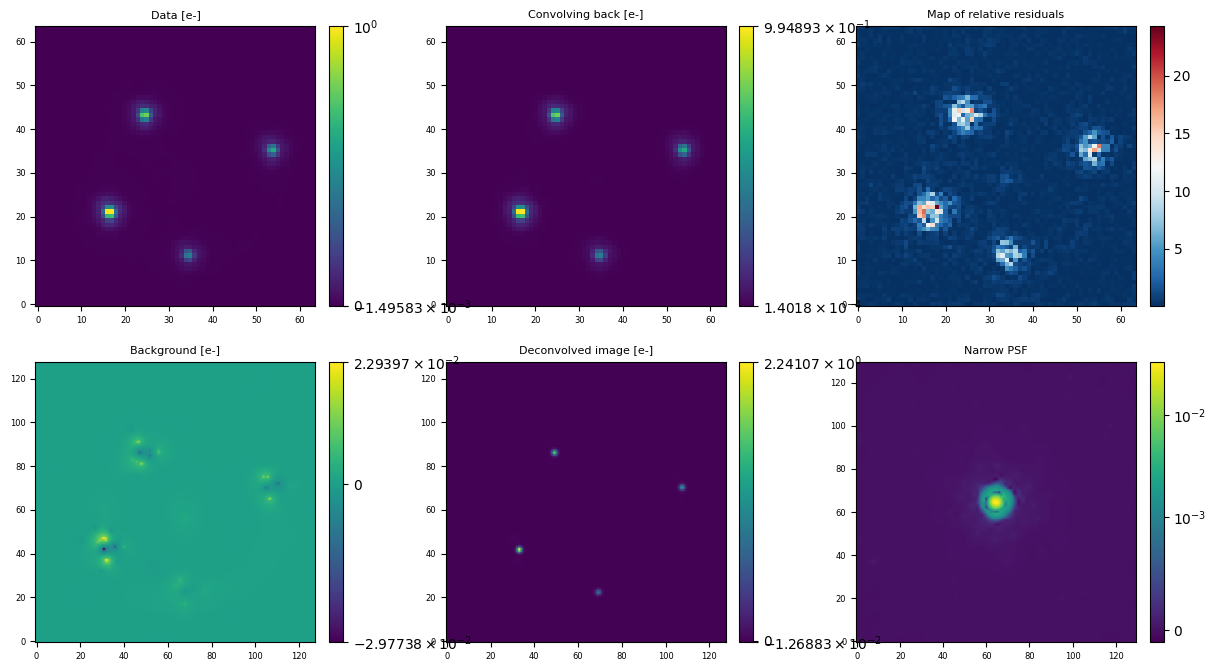

In [76]:
#lambda_scales=1., lambda_hf=1000., lambda_positivity_bkg=100, lambda_positivity_ps=100,lambda_pts_source=0.
#Since we have no regularisation, we can use 'l-bfgs-b'. 
fitting_sequence=[['background']]#, ['pts-source-astrometry'], []],
optim_list = ['l-bfgs-b']
model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = (
    multi_steps_deconvolution(
        data,
        model,
        parameters,
       sigma2,
        narrow_psfs,
        subsampling_factor=subsampling_factor,
        lambda_scales=0., lambda_hf=0., lambda_positivity_bkg=100, lambda_positivity_ps=100,
        lambda_pts_source=0., prior_list=None, regularize_full_model=True,num_samples_noise=500,
        update_lambda_pts_source=False,adjust_sky=False,optim_list=optim_list,fitting_sequence=fitting_sequence
    )
)
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
view_deconv_model(model, kwargs_partial, data, sigma2)

#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry'], #step 1 : fix the Sersic profile and the astrometry, release the background
        ]
    
optim_list = ['adabelief']
kwargs_optax1 = {'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 5e-5, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }

kwargs_optim_list = [kwargs_optax1] 
prior_list=[None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 1, lambda_hf =1000, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))

{'kwargs_analytic': {'a': Array([ 5.97526295,  4.37326073,  8.15455703, 10.93180772], dtype=float64), 'c_x': Array([ 22.22660649,   3.09483586,  -6.93153875, -14.98399308], dtype=float64), 'c_y': Array([  3.60035081, -20.35218831,  11.54333167, -10.65982162], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([1.89899730e-05, 1.68915733e-05, 3.02662483e-05, ...,
       2.81303029e-05, 1.55296693e-05, 1.62336796e-05], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Overall Reduced Chi2 :  2.761821573036251


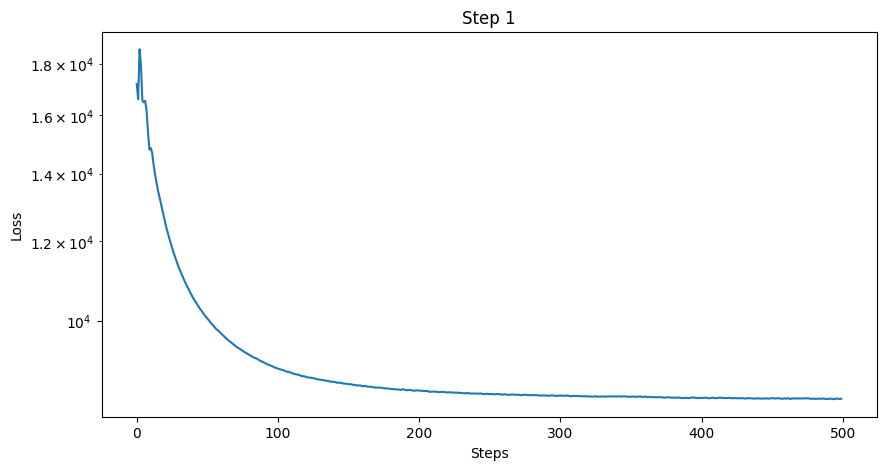

In [78]:
for i in range(len(loss_history_list)):
    #print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

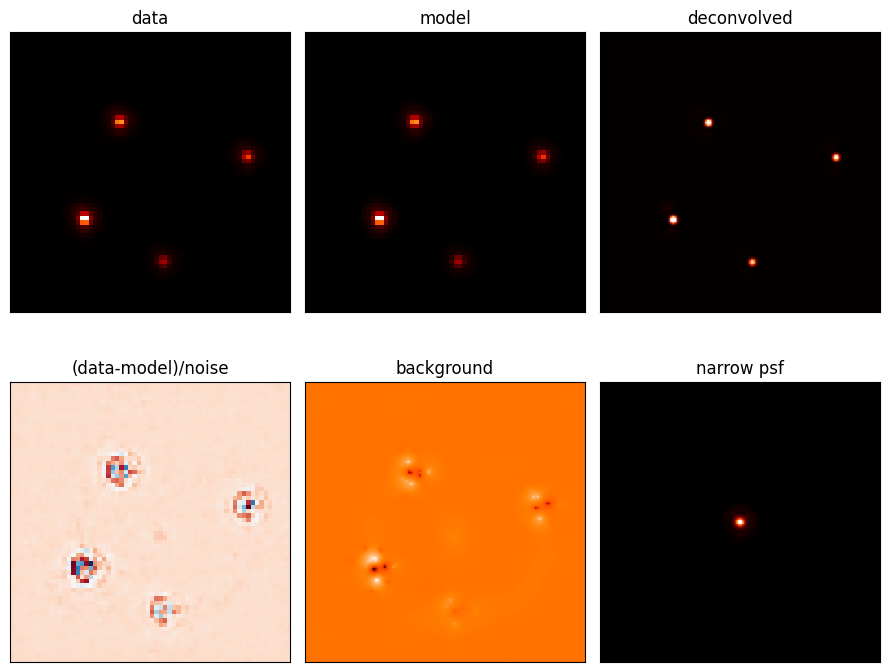

In [80]:
view_deconv_model(model, kwargs_final, data, sigma2)

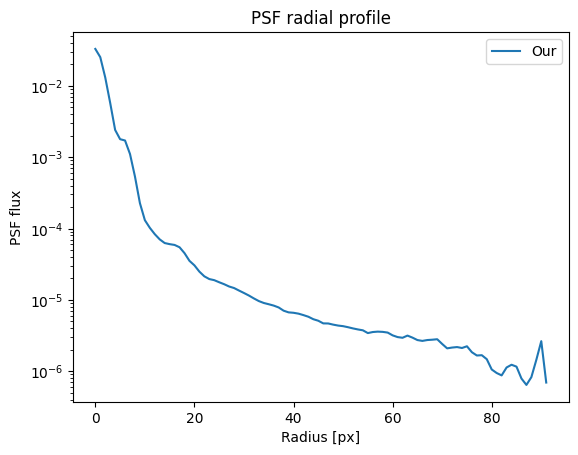

In [214]:
# Radial profile of your PSF
psf = narrow_psfs[0]  # or whichever band
#psf = full_psf
cy, cx = np.array(psf.shape) // 2
y, x = np.indices(psf.shape)
r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
radial_profile = np.bincount(r.ravel(), psf.ravel()) / np.bincount(r.ravel())
plt.semilogy(radial_profile,label="Our")
#plt.ylim(1e-7)
plt.xlabel("Radius [px]"); plt.ylabel("PSF flux"); plt.title("PSF radial profile")
plt.legend()

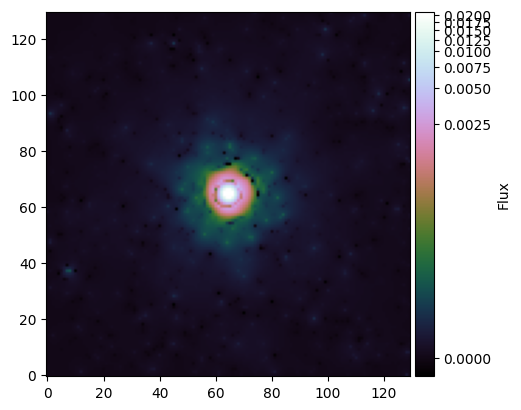

In [215]:
from SFstarred.plots import twoplot,plot_star_mask,plot_stars_features,nice_psf_plot
nice_psf_plot(narrow_psfs[0],percent=99.9,cmap="cubehelix")

# convolving a star 

In [355]:
data_raw = data_dict["stars_data"].copy()[[3]]
sigma2 = data_dict['stars_sigma2'].copy()[[3]]
im_size = data_raw.shape[1]
exptime_seconds = data_dict["exptime_seconds"]

In [356]:
#data = data*exptime_seconds
# _, _,final_mask,diagnostics = normalize_data_error_photutils(data[0],np.sqrt(sigma2)[0],exptime_seconds=exptime_seconds,input_in_electrons=True)
#similar
import sep
import numpy as np

data_sep = np.ascontiguousarray(data_raw[0].astype(np.float64))

bkg = sep.Background(
    data_sep,
    mask=None,
    bw=32,
    bh=32,
    fw=3,
    fh=3,
)

background = bkg.back()
background_rms = bkg.rms()

print(np.mean(background),np.mean(background_rms))



image_positions = data_dict["coord_pix_images"]
image_names = data_dict["images_names"]
coord_pix_images_dict = data_dict["coord_pix_images_dict"]



0.006004401891211257 0.0018685561393183717


In [357]:
obj, seg = sep.extract(data_sep, thresh=2.0,
                        err=np.sqrt(np.median(sigma2)),
                        segmentation_map=True)
source_mask = seg > 0
from scipy.ndimage import binary_dilation
source_mask = binary_dilation(source_mask, iterations=3)

bkg = sep.Background(data_sep, mask=source_mask, bw=32, bh=32, fw=3, fh=3)
background = bkg.back()        # 2D map
background_rms = bkg.rms()     # 2D map
#data = data_raw - np.mean(background)
data = (data_raw[0] - background)[None,:,:]
sigma2 = (sigma2[0] + background_rms**2 + np.clip(data, 0, None))
scale = np.max(data)
#noise_map = np.sqrt(variance_map)


In [358]:
source_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(65, 65))

In [359]:
data[:,~source_mask]=0
sigma2[:,~source_mask] = 0

In [360]:
# results = subtract_background_and_mask_contaminants(
#     data_raw=data_raw,
#     sigma2=sigma2,
#     main_position=(25.0, 19.0),   # x, y
#     detection_thresh=1.5,
#     contaminant_dilation=8,
# )

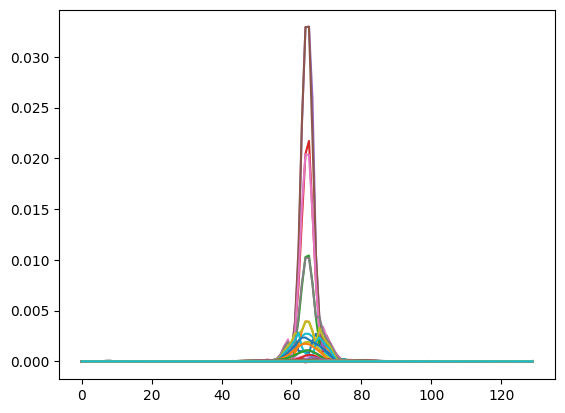

In [378]:
for i in narrow_psfs[0]:
    plt.plot(i)
    #break

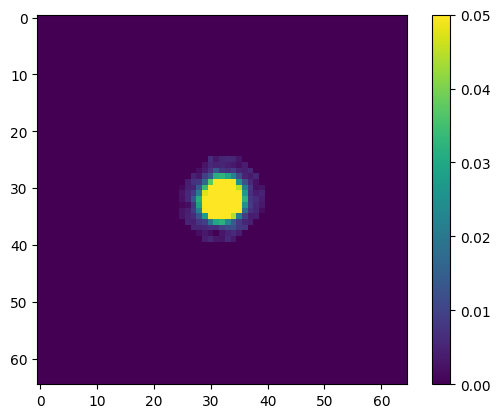

In [362]:
plt.imshow(data[0],vmin=-1e-5,vmax=0.05)
plt.colorbar()

In [363]:
wht = 1/sigma2[0]  # rename for clarity, since this is weight not variance
var_inst = np.zeros_like(wht)
good = wht > 0
var_inst[good] = 1/wht[good]
var_inst[~good] = np.inf   # or flag these pixels in a separate bad-pixel mask
poisson_var = np.clip(data, 0, None) / exptime_seconds

sigma2 = var_inst + background_rms**2 + np.clip(data, 0, None) #/ exptime_seconds
#noise_map = np.sqrt(variance_map)

/var/folders/9p/9nd87mkj1278f_ny5pgsc0zc0000gn/T/ipykernel_35222/3325213919.py:1: RuntimeWarning: divide by zero encountered in divide
  wht = 1/sigma2[0]  # rename for clarity, since this is weight not variance


In [374]:
sigma2 /=scale**2
data /=scale

{'kwargs_analytic': {'c_x': array([0]), 'c_y': array([0]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([9.94016682])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(16900,)), 'mean': array([0.])}}


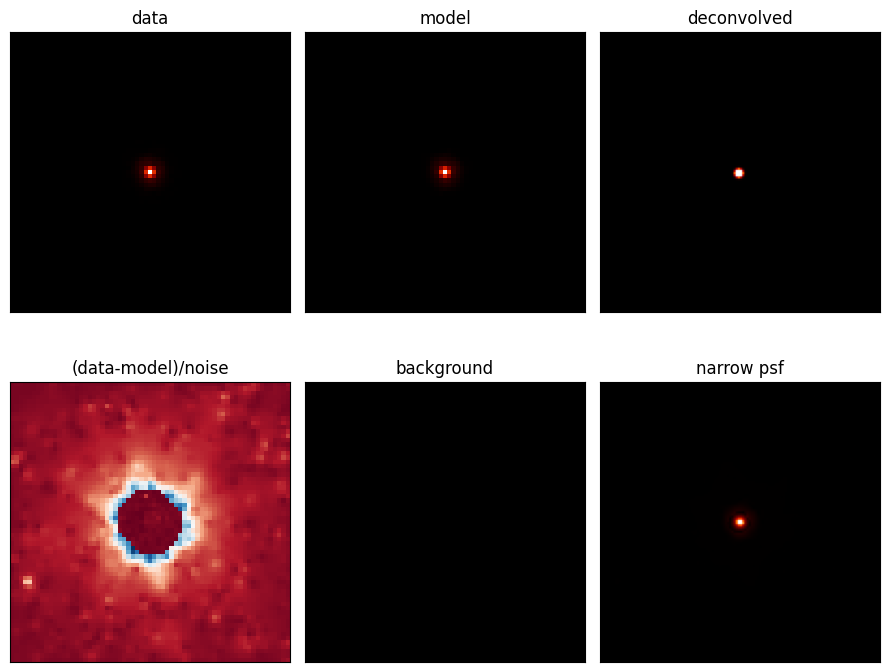

In [375]:
initial_c_x = [0]
initial_c_y = [0]


brightnesses = len(data) * 1 * [10]
subsampling_factor = 2
model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(
    data,
    sigma2,
    narrow_psfs,
    initial_c_x,
    initial_c_y,
    subsampling_factor=subsampling_factor,
    initial_a=brightnesses,
    N_sersic=0,
)

# kwargs_init['kwargs_sersic']['amp'][0] = 0.01
# kwargs_init['kwargs_sersic']['e1'][0] = -0.1
# kwargs_init['kwargs_sersic']['e2'][0] = -0.1
# kwargs_init['kwargs_sersic']['center_x'][0] = 2.41209164
# kwargs_init['kwargs_sersic']['center_y'][0] = -3.25006249

parameters = ParametersDeconv(
    kwargs_init,
    kwargs_fixed,
    kwargs_up=kwargs_up,
    kwargs_down=kwargs_down,
)

print(kwargs_init)
view_deconv_model(model, kwargs_init, data,sigma2)

Step 1, fixing : ['pts-source-astrometry', 'background']
Step 1/2 took  0 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([0.15045589], dtype=float64), 'c_x': Array([0.], dtype=float64), 'c_y': Array([0.], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  2.1687208597586802
Overall Reduced Chi2 :  0.0010266134247378367
Step 2, fixing : ['background']
Step 2/2 took  0 seconds
Kwargs partial at step 2/2 {'kwargs_analytic': {'a': A

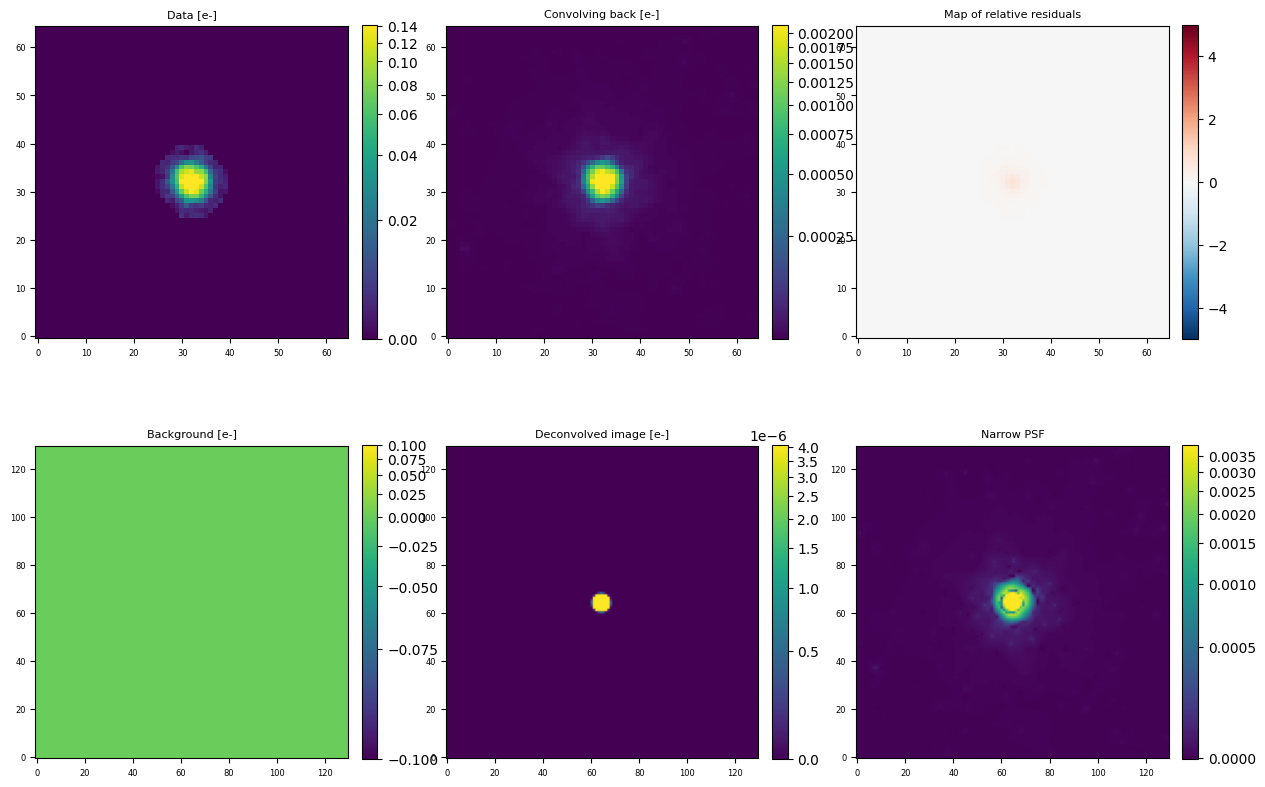

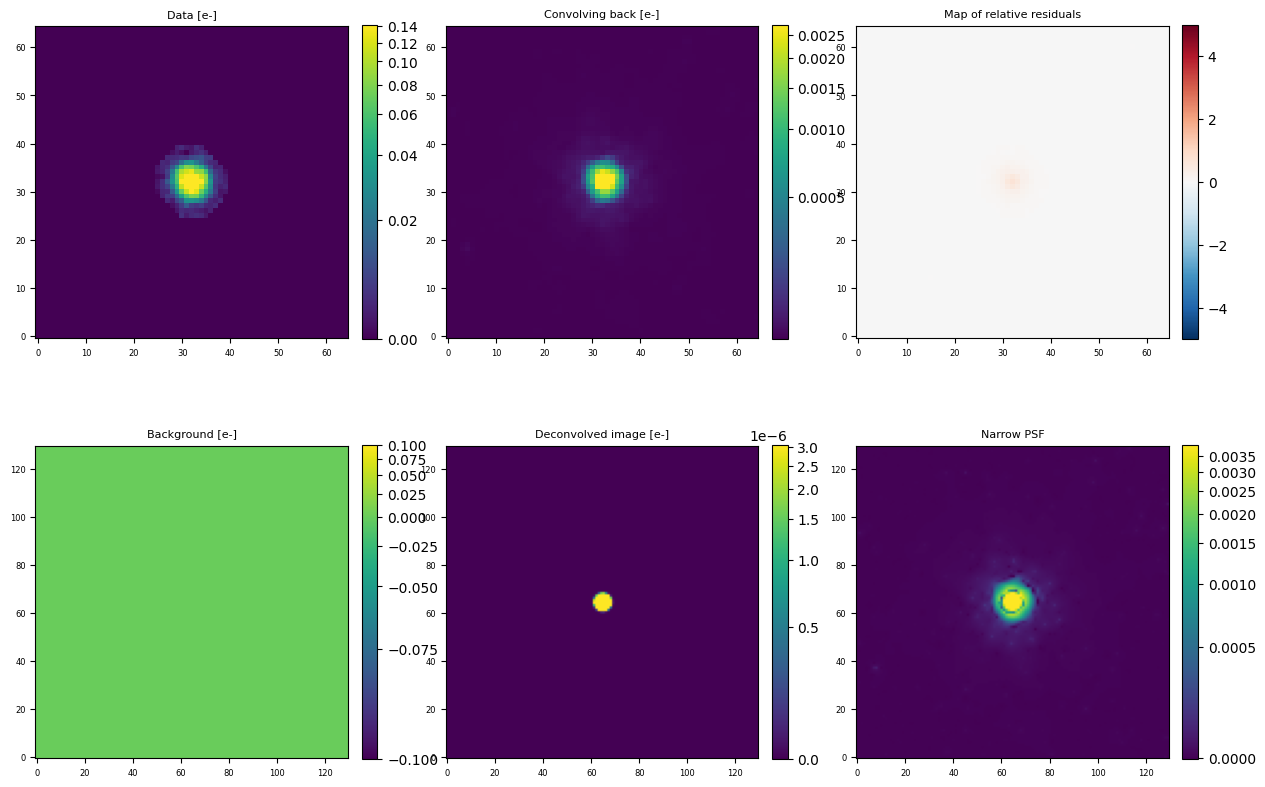

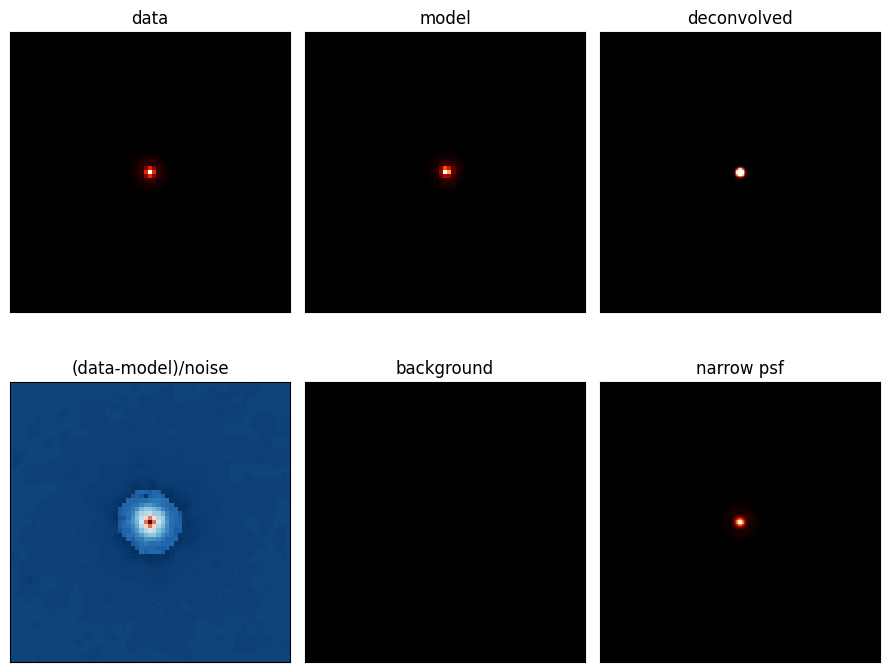

In [376]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':50}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, lambda_positivity_bkg=0,
                                                                                    lambda_positivity_ps=0, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
#pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data, sigma2)

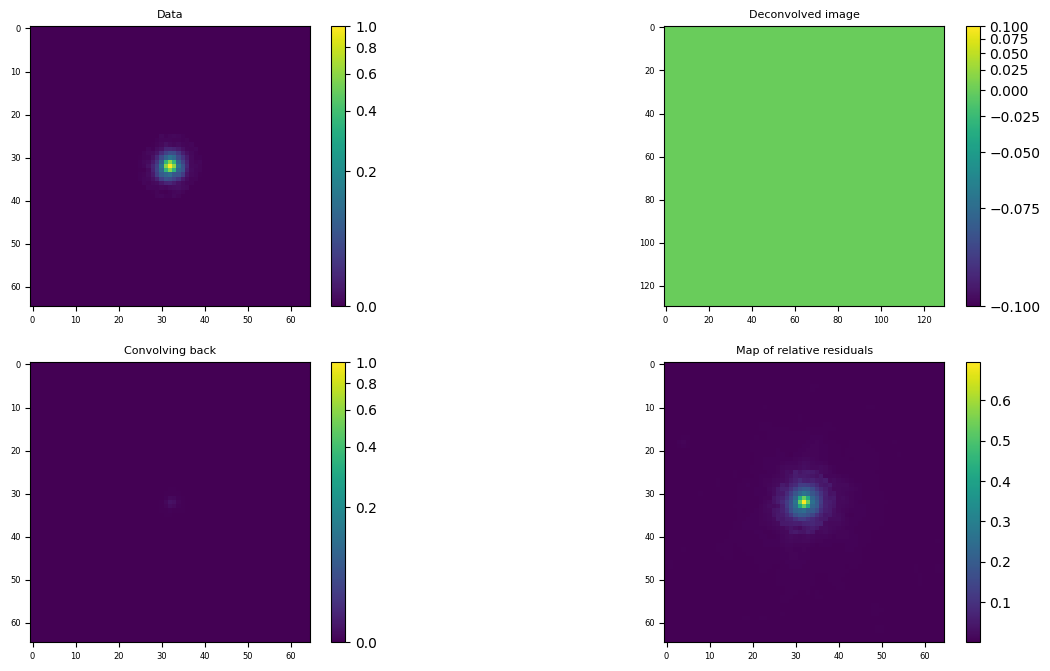

In [367]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_partial)[epoch]
deconv, h = model.getDeconvolved(kwargs_partial, epoch)

data_show = data[epoch,:,:] 

dif = data_show - output
rr = np.abs(dif)/ np.sqrt(sigma2[epoch,:,:])

fig, axs = plt.subplots(2, 2, figsize=(15,8))
fraction = 0.046
pad = 0.04
font_size = 10
ticks_size = 6

from astropy.visualization import (imshow_norm, MinMaxInterval,
                                   SqrtStretch, AsinhStretch)
stretch = AsinhStretch

plt.rc('font', size=font_size)           
axs[0,0].set_title('Data', fontsize=8)
axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[0,1].set_title('Deconvolved image', fontsize=8)
axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,0].set_title('Convolving back', fontsize=8)
axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,1].set_title('Map of relative residuals', fontsize=8)
axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
plt.show()


In [368]:
subsampling_factor

2

Step 1, fixing : ['pts-source-astrometry']


optax.adabelief: 100%|██████████| 1000/1000 [00:03<00:00, 272.51it/s]


Step 1/1 took  4 seconds
Kwargs partial at step 1/1 {'kwargs_analytic': {'a': Array([0.10628362], dtype=float64), 'c_x': Array([0.31779688], dtype=float64), 'c_y': Array([0.13144886], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([ 9.52748056e-06,  8.96013696e-06,  2.02436589e-06, ...,
       -9.83357178e-07,  2.33134467e-06,  6.46754110e-06], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  4.5657150649362865
Overall Reduced Chi2 :  0.0012303012490182726


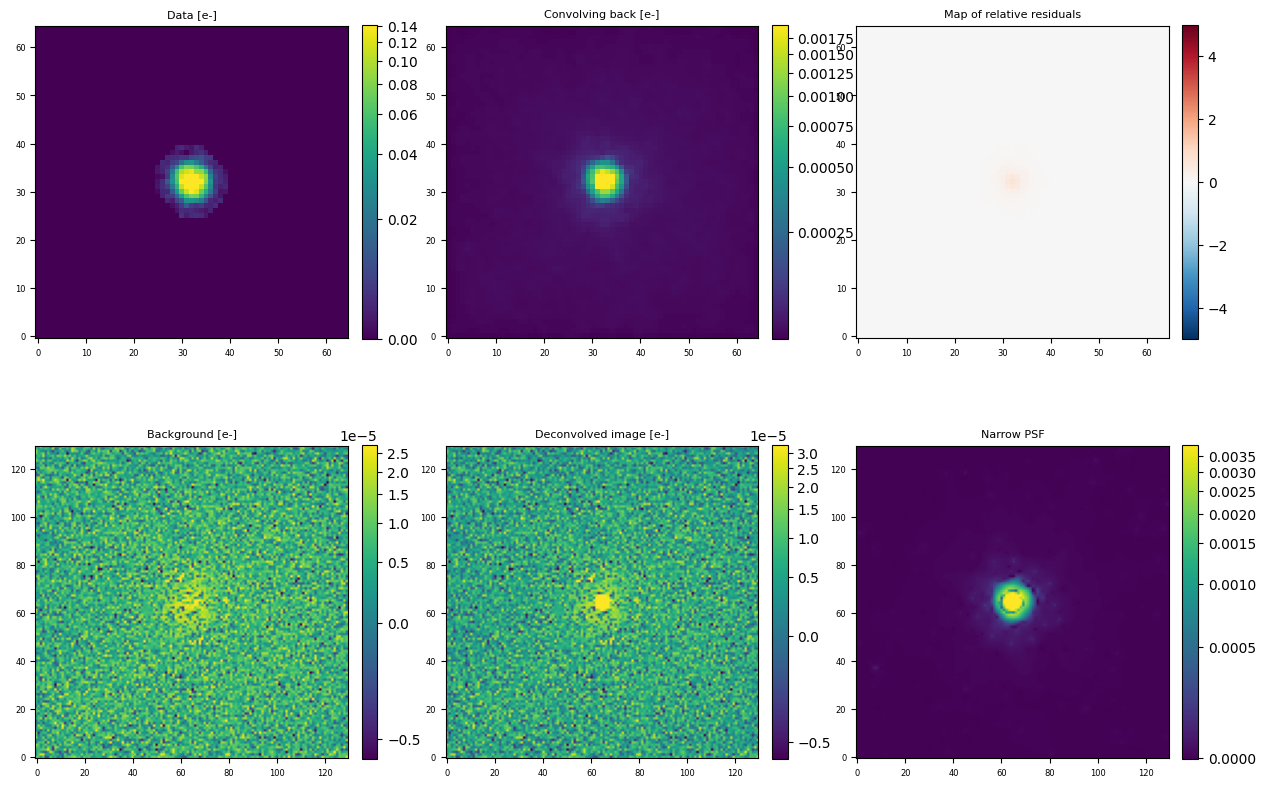

In [370]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry'],
                    #[]
                    #['sersic', 'pts-source-astrometry'], #step 1 : fix the Sersic profile and the astrometry, release the background
                    #['sersic'],
        ]
    
optim_list = ['adabelief']
kwargs_optax1 = {'max_iterations': 1_000, 'min_iterations': None,
        'init_learning_rate': 3e-5, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optim_list = [kwargs_optax1] 
prior_list=[None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)
#for ls in np.arange(1,5):
model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 4, lambda_hf =4, 
                                                                                    lambda_positivity_ps=100,
                                                                                    lambda_positivity_bkg=100,
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, optimiser adabelief
{'kwargs_analytic': {'a': Array([0.10628362], dtype=float64), 'c_x': Array([0.31779688], dtype=float64), 'c_y': Array([0.13144886], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([ 9.52748056e-06,  8.96013696e-06,  2.02436589e-06, ...,
       -9.83357178e-07,  2.33134467e-06,  6.46754110e-06], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Overall Reduced Chi2 :  0.0012303012490182726


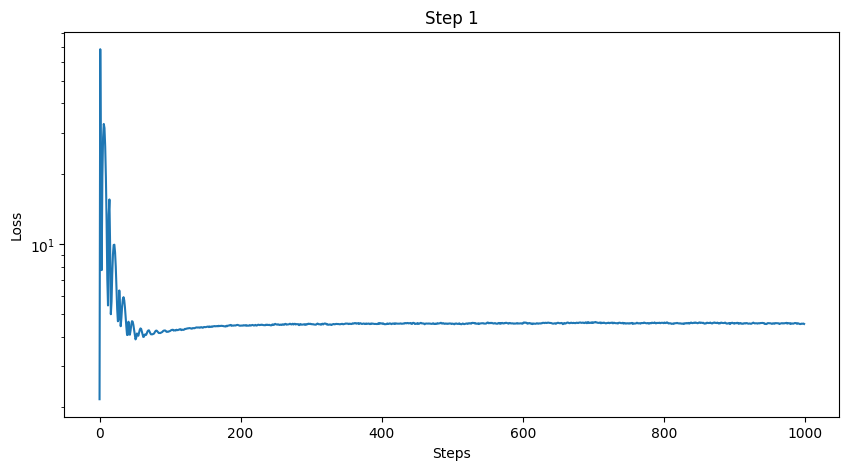

In [371]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

In [372]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_final)[epoch]
deconv, h = model.getDeconvolved(kwargs_final, epoch)

data_show = data[epoch,:,:] 

dif = data_show - output
rr = np.abs(dif)/ np.sqrt(sigma2[epoch,:,:])

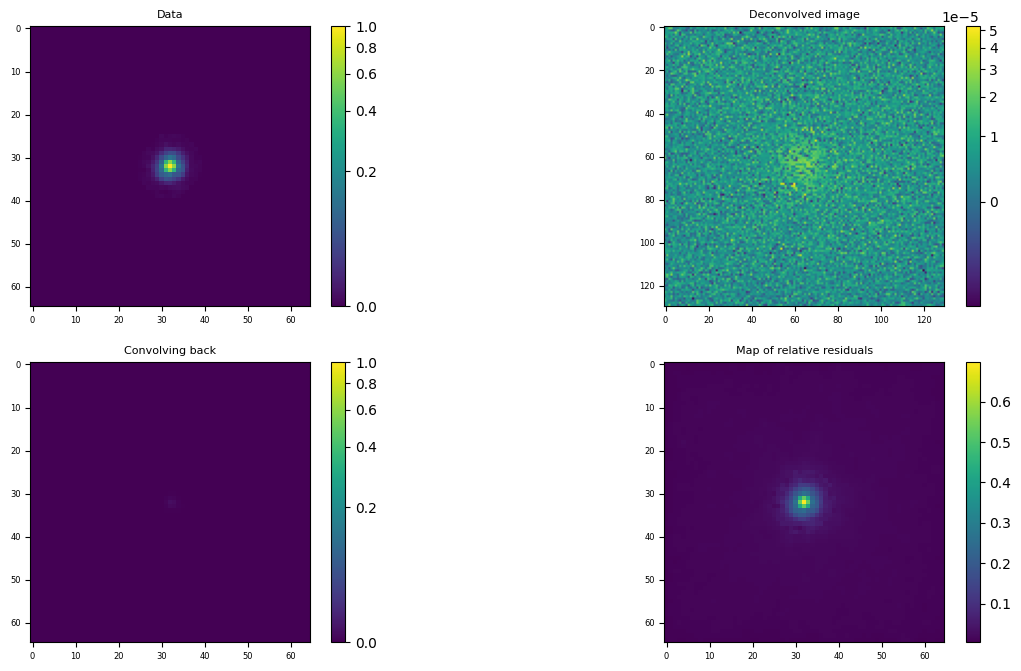

In [373]:
fig, axs = plt.subplots(2, 2, figsize=(15,8))
fraction = 0.046
pad = 0.04
font_size = 10
ticks_size = 6

from astropy.visualization import (imshow_norm, MinMaxInterval,
                                   SqrtStretch, AsinhStretch)
stretch = AsinhStretch

plt.rc('font', size=font_size)           
axs[0,0].set_title('Data', fontsize=8)
axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[0,1].set_title('Deconvolved image', fontsize=8)
axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,0].set_title('Convolving back', fontsize=8)
axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,1].set_title('Map of relative residuals', fontsize=8)
axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
plt.show()